# **Assignment 2: PM₂.₅ Time-Series Analysis for Delhi Monitoring Stations (2022)**

# **Submission Notebook**

**NOTE TO REVIEWER**

*This notebook performs time-series analysis using PM₂.₅ datasets from five monitoring stations (Narela, North Campus, Nehru Nagar, R K Puram, ITO) in Delhi and all required tasks (1-4) of Assignment 2.*

*(data downloaded from the given link)*  

**The tasks include:**

- Loading and preparing merged observation data  
- Visual comparison of diurnal patterns  
- Weekly and monthly temporal aggregation  
- Trend visualization and interpretation  

*The outputs will help understand how PM₂.₅ concentration varies across time scales*.

# **Pre-Requisite Setup**

**Install and Import Required Libraries**

*This step ensures that all necessary Python packages are available.  
We install libraries for:*

- **`xarray`** → handling structured scientific data  
- **`pandas`** → tabular data processing  
- **`matplotlib`** → plotting time-series visualizations  
- **`scikit-learn`** → statistical evaluation or modelling

*Once installed, we import them and load the merged PM₂.₅ dataset for analysis.*

In [ ]:
!pip install xarray pandas geopandas scipy scikit-learn

# **Processing, Cleaning, and Merging Ground & Satellite PM₂.₅ Data (2022)**

*This section of the notebook performs the complete workflow required to prepare PM₂.₅ datasets from both ground monitoring stations and the satellite-derived WUSTL product for Delhi (2022).*  

**The code executes the following tasks:**

- Imports all required scientific and utility libraries.
- Loads raw daily CSV files from five pollution monitoring stations in Delhi and cleans them by:
  - Formatting timestamps
  - Extracting the PM₂.₅ variable
  - Removing missing and invalid values  
- Extracts the satellite data from the provided ZIP archive and locates all available `.nc` files for the year.
- Applies scaling corrections, removes fill values, and subsets the data spatially using a bounding box for Delhi.
- Concatenates all monthly satellite files into a single continuous dataset.
- Uses spatial interpolation (KD-Tree nearest neighbour) to extract satellite PM₂.₅ values at the exact coordinates of each monitoring station.
- Resamples both datasets to a monthly time resolution and merges them into one final comparative dataframe.
- Saves the processed output as:  
  **`PM25_Satellite_vs_Ground_2022_CORRECTED.csv`**

*This combined dataset will be used in later steps to assess agreement, visualize trends, and evaluate the performance of satellite-derived PM₂.₅ estimates relative to observed station measurements.*

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import os
import zipfile
import glob
import gc
import warnings
from scipy.spatial import cKDTree
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

warnings.filterwarnings("ignore")

PM25_ZIP_FILE = "2022.zip"
PM25_VAR_NAME = "PM25"

CONVERSION_FACTOR = 1.0

STATION_COORDS = {
    'Narela': (77.0682, 28.8475),
    'North Campus': (77.2039, 28.6946),
    'Nehru Nagar': (77.2559, 28.5638),
    'R K Puram': (77.1868, 28.5638),
    'ITO': (77.2405, 28.6322)
}
STATION_NAMES = list(STATION_COORDS.keys())

DELHI_BBOX = {
    "lat_min": 27.5, "lat_max": 29.5,
    "lon_min": 76.0, "lon_max": 78.5
}

CSV_FILES = [
    'Raw_data_1Day_2022_site_1426_Narela_Delhi_DPCC_1Day.csv',
    'Raw_data_1Day_2022_site_105_North_Campus_DU_Delhi_IMD_1Day.csv',
    'Raw_data_1Day_2022_site_1429_Nehru_Nagar_Delhi_DPCC_1Day.csv',
    'Raw_data_1Day_2022_site_124_R_K_Puram_Delhi_DPCC_1Day.csv',
    'Raw_data_1Day_2022_site_117_ITO_Delhi_CPCB_1Day.csv'
]

print("1) Loading observed station CSVs...")
cleaned_dfs = {}

for filepath in CSV_FILES:
    try:
        station_name_raw = filepath.split('_site_')[1].split('_Delhi_')[0].replace('_', ' ')
    except:
        station_name_raw = filepath
    station_name = next((s for s in STATION_NAMES if s.replace(' ', '').lower() in station_name_raw.replace(' ', '').lower()), None)

    if not station_name:
        continue

    try:
        df = pd.read_csv(filepath)
        col_map = {c: 'Timestamp' for c in df.columns if c.lower() == 'timestamp'}
        df.rename(columns=col_map, inplace=True)

        df['Timestamp'] = pd.to_datetime(df['Timestamp'])
        df = df.set_index('Timestamp')

        pm_col = next((c for c in df.columns if 'PM2.5' in c or c.replace('.', '').upper() == 'PM25'), None)
        if pm_col:
            df = df[[pm_col]].dropna()
            df = df[df[pm_col] > 0]
            cleaned_dfs[station_name] = df.rename(columns={pm_col: station_name})
    except Exception as e:
        print(f"Error reading {filepath}: {e}")

if not cleaned_dfs:
    raise ValueError("No observed data loaded! Check CSV paths.")

observed_pm25 = pd.concat(cleaned_dfs.values(), axis=1).resample('D').mean()
print(f"Observed data loaded: {observed_pm25.shape}")

print("\n2) Extracting and Processing Satellite Data...")
extract_dir = "2022_extracted"
os.makedirs(extract_dir, exist_ok=True)
if not os.path.exists(extract_dir) or not os.listdir(extract_dir):
    with zipfile.ZipFile(PM25_ZIP_FILE, 'r') as zf:
        zf.extractall(extract_dir)

nc_files = sorted(glob.glob(os.path.join(extract_dir, '**', '*.nc'), recursive=True))
print(f"   Found {len(nc_files)} .nc files.")

datasets = []

for f in nc_files:
    ds = xr.open_dataset(f)

    try:
        date_str = f.split(".AS.")[-1].split(".nc")[0]
        year_month = date_str.split("-")[0]
        dt = pd.to_datetime(year_month, format="%Y%m")
    except:
        import re
        m = re.search(r'20\d{4}', os.path.basename(f))
        dt = pd.to_datetime(m.group(0), format="%Y%m") if m else pd.Timestamp("2022-01-01")

    ds = ds.expand_dims(time=[dt])

    raw = ds[PM25_VAR_NAME]
    scale = raw.attrs.get("scale_factor", 1)
    offset = raw.attrs.get("add_offset", 0)
    fill = raw.attrs.get("_FillValue", None)

    pm_data = raw * scale + offset
    if fill is not None:
        pm_data = pm_data.where(raw != fill)

    pm_data = pm_data * CONVERSION_FACTOR

    ds[PM25_VAR_NAME] = pm_data

    ds = ds.sel(
        lat=slice(DELHI_BBOX["lat_min"], DELHI_BBOX["lat_max"]),
        lon=slice(DELHI_BBOX["lon_min"], DELHI_BBOX["lon_max"])
    )

    datasets.append(ds)

print("\n3) Concatenating monthly files...")
ds_delhi = xr.concat(datasets, dim="time")
ds_delhi = ds_delhi.sortby("time")
print(f"Final Satellite Shape: {ds_delhi[PM25_VAR_NAME].shape}")

print("\n4) Interpolating to Station Coordinates...")

lat_vals = ds_delhi["lat"].values
lon_vals = ds_delhi["lon"].values
lon_grid, lat_grid = np.meshgrid(lon_vals, lat_vals)
grid_points = np.column_stack((lon_grid.ravel(), lat_grid.ravel()))

tree = cKDTree(grid_points)

df_interp = pd.DataFrame(index=ds_delhi["time"].values)

for name, coords in STATION_COORDS.items():
    target_lon, target_lat = coords
    dist, idx = tree.query([(target_lon, target_lat)])
    y_index, x_index = np.unravel_index(idx, lat_grid.shape)
    pixel_values = ds_delhi[PM25_VAR_NAME][:, y_index, x_index].values.flatten()
    df_interp[f"{name}_WUSTL"] = pixel_values

df_interp.index.name = "Timestamp"
print("Interpolation done.")


print("\n5) Merging with Observed Data...")
observed_monthly = observed_pm25.resample('MS').mean()

final_df = observed_monthly.join(df_interp, how='inner')
final_df.to_csv("PM25_Satellite_vs_Ground_2022_CORRECTED.csv")

print("Saved 'PM25_Satellite_vs_Ground_2022_CORRECTED.csv'")
print(final_df.head())

1) Loading observed station CSVs...
Observed data loaded: (365, 5)

2) Extracting and Processing Satellite Data...
   Found 12 .nc files.

3) Concatenating monthly files...
Final Satellite Shape: (12, 200, 250)

4) Interpolating to Station Coordinates...
Interpolation done.

5) Merging with Observed Data...
Saved 'PM25_Satellite_vs_Ground_2022_CORRECTED.csv'
                Narela  North Campus  Nehru Nagar   R K Puram         ITO  \
Timestamp                                                                   
2022-01-01  158.236129    134.522581   208.437742  173.563871  180.026452   
2022-02-01  125.427500     94.208214   146.805357  117.823929  119.025000   
2022-03-01  116.079032     83.187419   111.030000  104.584839  117.737742   
2022-04-01  139.793333     89.968667   106.792000  108.044000   90.593667   
2022-05-01   84.756333     70.471935    80.607419   83.852903   93.300323   

            Narela_WUSTL  North Campus_WUSTL  Nehru Nagar_WUSTL  \
Timestamp                       

# **Task 2.1 — Time Series Plot: Observed vs Satellite PM₂.₅**

*This cell loads the processed PM₂.₅ dataset and creates time-series plots for each monitoring station, comparing ground observations with satellite-derived WUSTL values.*  

*The plots help visualize how closely the satellite data follows the real measured pollution levels throughout 2022.*

Loaded PM25_Satellite_vs_Ground_2022_CORRECTED.csv
Generating plots for: ['Narela', 'North Campus', 'Nehru Nagar', 'R K Puram', 'ITO']


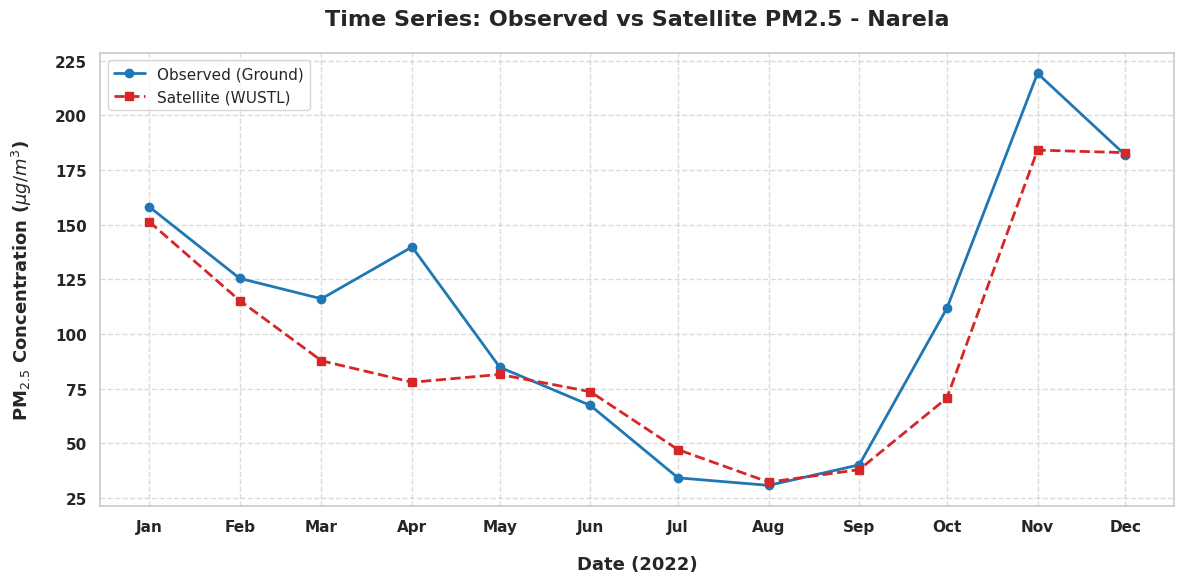

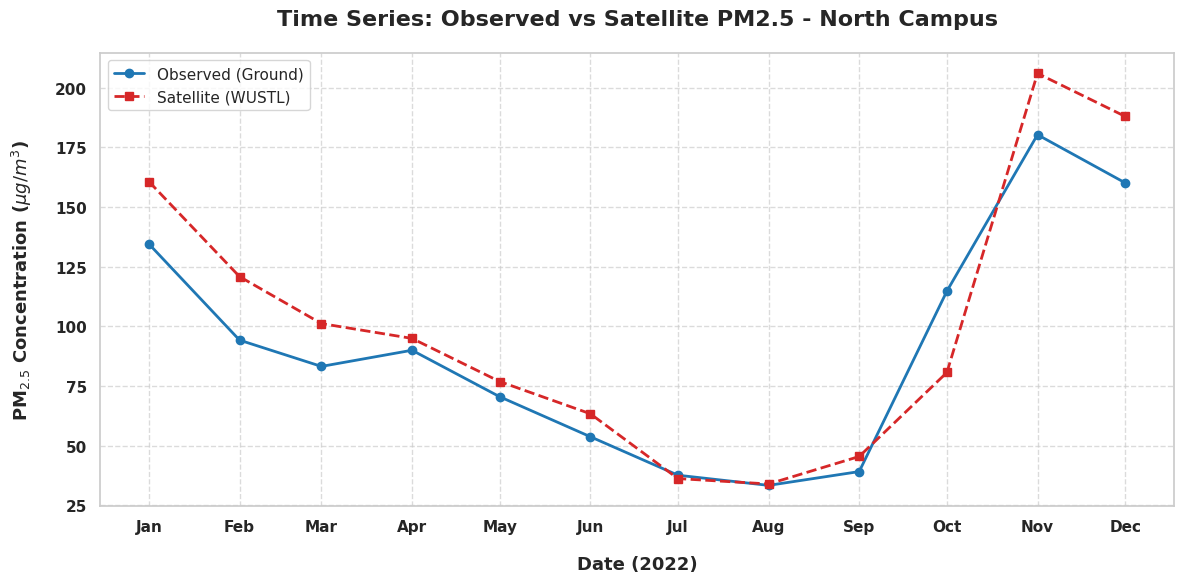

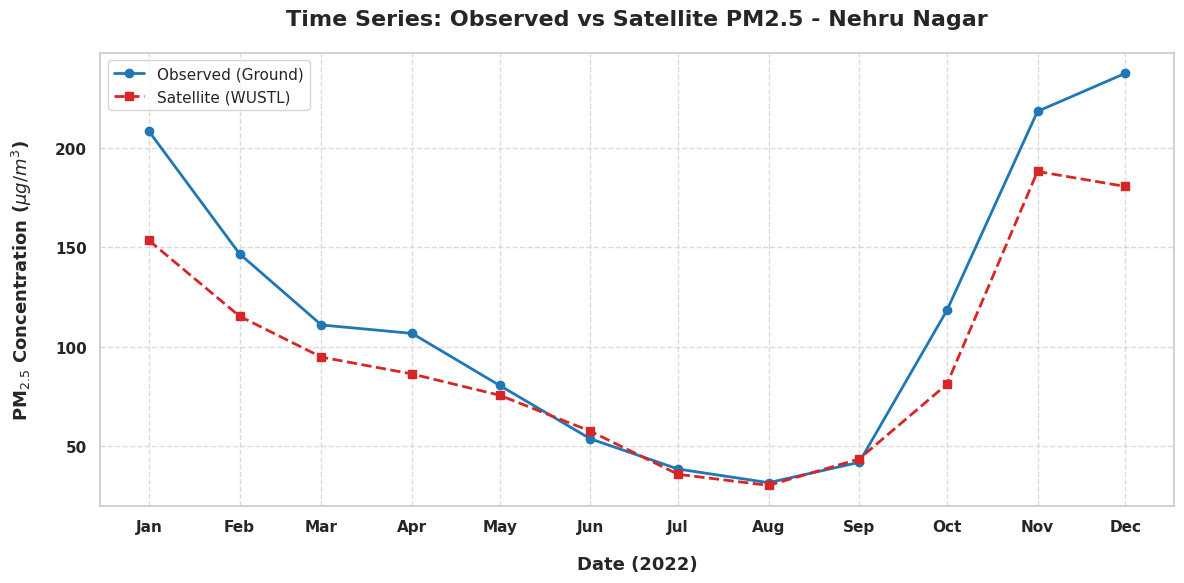

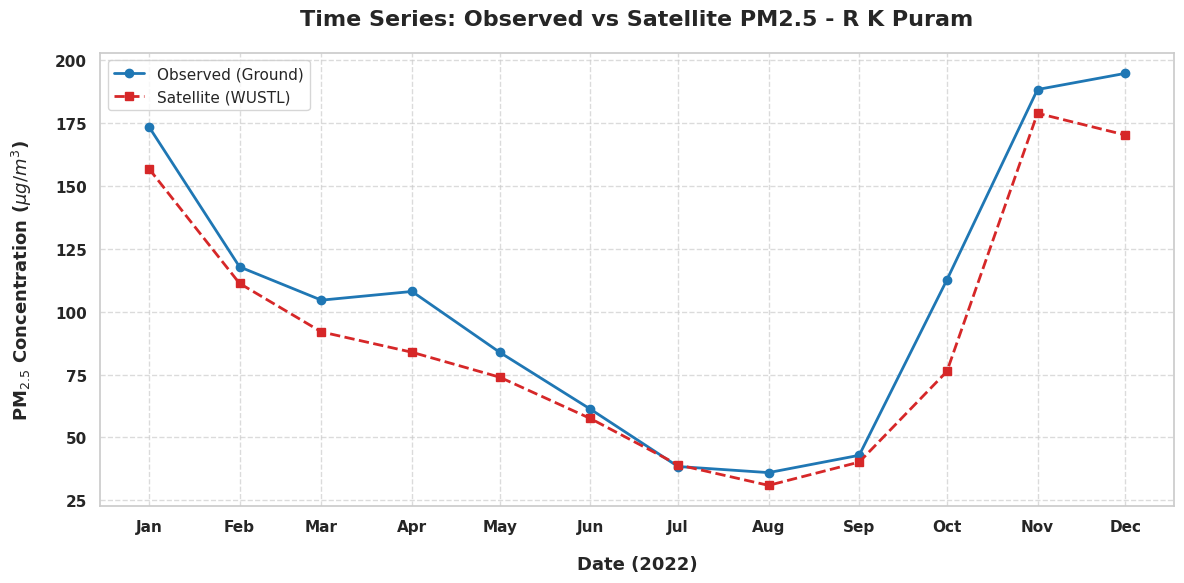

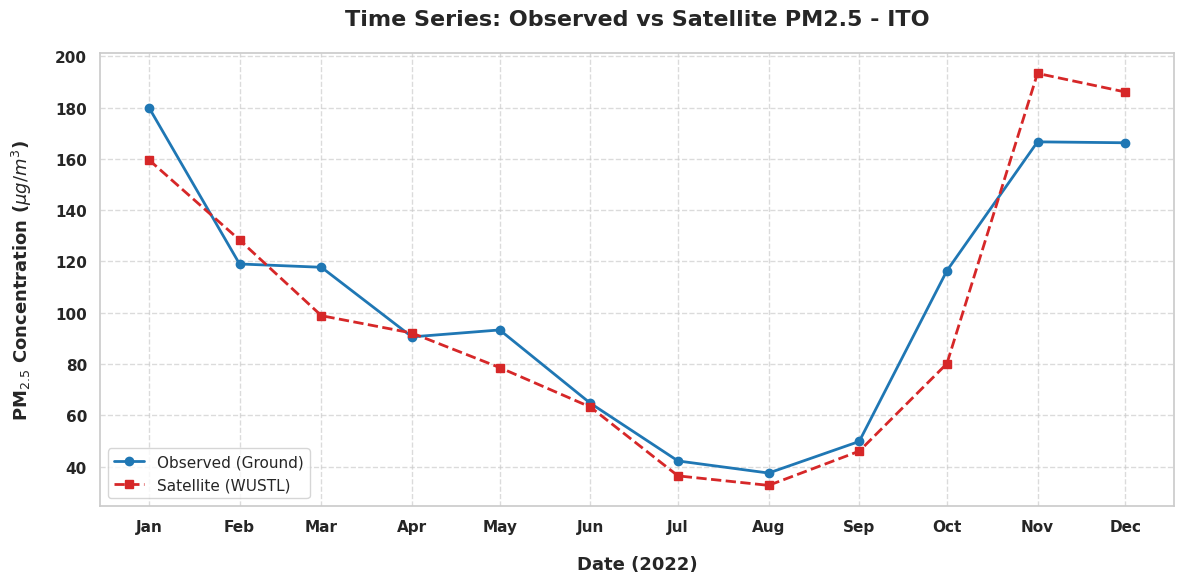

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.metrics import r2_score
import numpy as np

CSV_FILE = "PM25_Satellite_vs_Ground_2022_CORRECTED.csv"

try:
    df = pd.read_csv(CSV_FILE)
    if 'Timestamp' in df.columns:
        df['Timestamp'] = pd.to_datetime(df['Timestamp'])
        df = df.set_index('Timestamp')
    print(f"Loaded {CSV_FILE}")
except FileNotFoundError:
    print(f" Error: {CSV_FILE} not found.")
    exit()

stations = [c for c in df.columns if not c.endswith('_WUSTL')]
sns.set_theme(style="whitegrid")

print(f"Generating plots for: {stations}")

for station in stations:
    obs_col = station
    sat_col = f"{station}_WUSTL"

    if sat_col not in df.columns:
        continue

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(df.index, df[obs_col], label='Observed (Ground)',
             color='#1f77b4', marker='o', linewidth=2, markersize=6)

    ax.plot(df.index, df[sat_col], label='Satellite (WUSTL)',
             color='#d62728', marker='s', linestyle='--', linewidth=2, markersize=6)

    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

    ax.set_title(f"Time Series: Observed vs Satellite PM2.5 - {station}", fontsize=16, fontweight='bold', pad=20)
    ax.set_ylabel("PM$_{2.5}$ Concentration ($\mu g/m^3$)", fontsize=13, fontweight='bold', labelpad=15)
    ax.set_xlabel("Date (2022)", fontsize=13, fontweight='bold', labelpad=15)

    ax.legend(fontsize=11)
    ax.grid(True, which='major', linestyle='--', alpha=0.7)

    plt.xticks(rotation=0, fontweight='bold')
    plt.yticks(fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\n" * 3)

## **Task 2.2 — Calculate Error Metrics for Observed vs Satellite PM₂.₅**

*This cell computes statistical performance metrics to evaluate how well the satellite-derived PM₂.₅ values match the ground observations for each monitoring station.*  

**The calculated metrics include:**

- **RMSE** – Root Mean Square Error  
- **MAE** – Mean Absolute Error  
- **MAPE** – Mean Absolute Percentage Error  
- **R² Score** – Goodness of fit  

*The results are formatted into a summary table for easy comparison across all stations.*

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

CSV_FILE = "PM25_Satellite_vs_Ground_2022_CORRECTED.csv"

try:
    df = pd.read_csv(CSV_FILE)
    if 'Timestamp' in df.columns:
        df['Timestamp'] = pd.to_datetime(df['Timestamp'])
        df = df.set_index('Timestamp')
    print(f"Loaded Data from {CSV_FILE}")
except FileNotFoundError:
    print(f"Error: {CSV_FILE} not found.")
    exit()

stations = [c for c in df.columns if not c.endswith('_WUSTL')]
long_results = []

print("\n Calculating Performance Metrics (RMSE, MAE, MAPE, R²)...\n")

for station in stations:
    obs_col = station
    sat_col = f"{station}_WUSTL"

    if sat_col not in df.columns:
        continue

    valid = df[[obs_col, sat_col]].dropna()

    if len(valid) < 2:
        print(f"Not enough data for {station}")
        continue

    y_true = valid[obs_col]
    y_pred = valid[sat_col]

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)

    long_results.append({'Station': station, 'Metric': 'RMSE (µg/m³)', 'Value': round(rmse, 2)})
    long_results.append({'Station': station, 'Metric': 'MAE (µg/m³)', 'Value': round(mae, 2)})
    long_results.append({'Station': station, 'Metric': 'MAPE (%)', 'Value': round(mape, 2)})
    long_results.append({'Station': station, 'Metric': 'R² Score', 'Value': round(r2, 3)})

if not long_results:
    print("No valid data found to calculate metrics.")
else:
    df_long = pd.DataFrame(long_results)

    pivot_table = df_long.pivot_table(index='Station', columns='Metric', values='Value')

    desired_order = ['RMSE (µg/m³)', 'MAE (µg/m³)', 'MAPE (%)', 'R² Score']

    cols_to_use = [c for c in desired_order if c in pivot_table.columns]
    pivot_table = pivot_table[cols_to_use]

    print("="*75)
    print("                       PERFORMANCE METRICS SUMMARY             ")
    print("="*75)
    try:
        print(pivot_table.to_markdown(tablefmt="pipe", numalign="center", stralign="center"))
    except ImportError:
        print(pivot_table)
    print("="*75 + "\n")

Loaded Data from PM25_Satellite_vs_Ground_2022_CORRECTED.csv

 Calculating Performance Metrics (RMSE, MAE, MAPE, R²)...

                       PERFORMANCE METRICS SUMMARY             
|   Station    |  RMSE (µg/m³)  |  MAE (µg/m³)  |  MAPE (%)  |  R² Score  |
|:------------:|:--------------:|:-------------:|:----------:|:----------:|
|     ITO      |     17.24      |     13.62     |   12.35    |   0.869    |
|    Narela    |     25.71      |     17.55     |   16.31    |   0.802    |
| Nehru Nagar  |     29.23      |     21.79     |   14.91    |   0.825    |
| North Campus |     19.41      |     15.65     |   15.41    |   0.826    |
|  R K Puram   |     16.39      |     12.71     |   11.63    |   0.909    |



# **Task 2.3 — PM₂.₅ Time-Series Pattern Analysis**

*This cell creates comparative plots for:*
- Diurnal variation  
- Daily variation  
- Weekly variation  
- Monthly variation  

*These visualizations help identify how PM₂.₅ levels change across time and between the five monitoring stations.*


Loaded Data. Shape: (8760, 5)


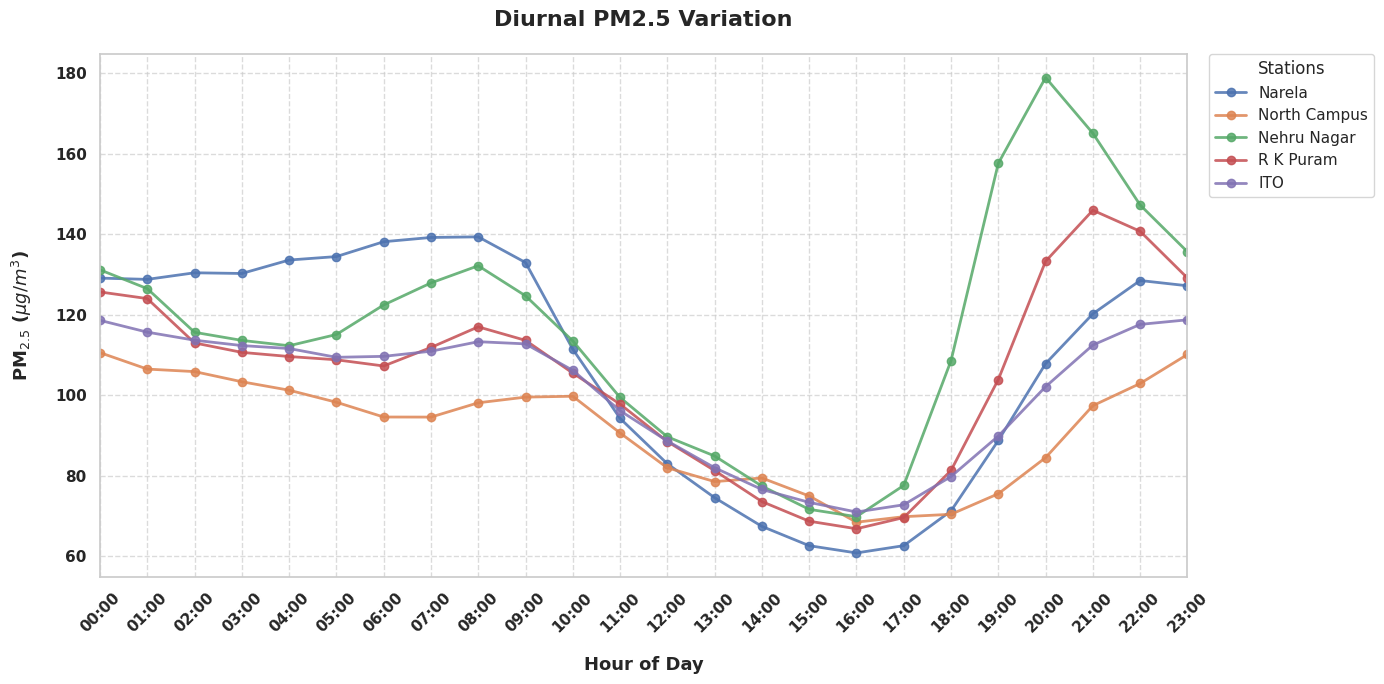

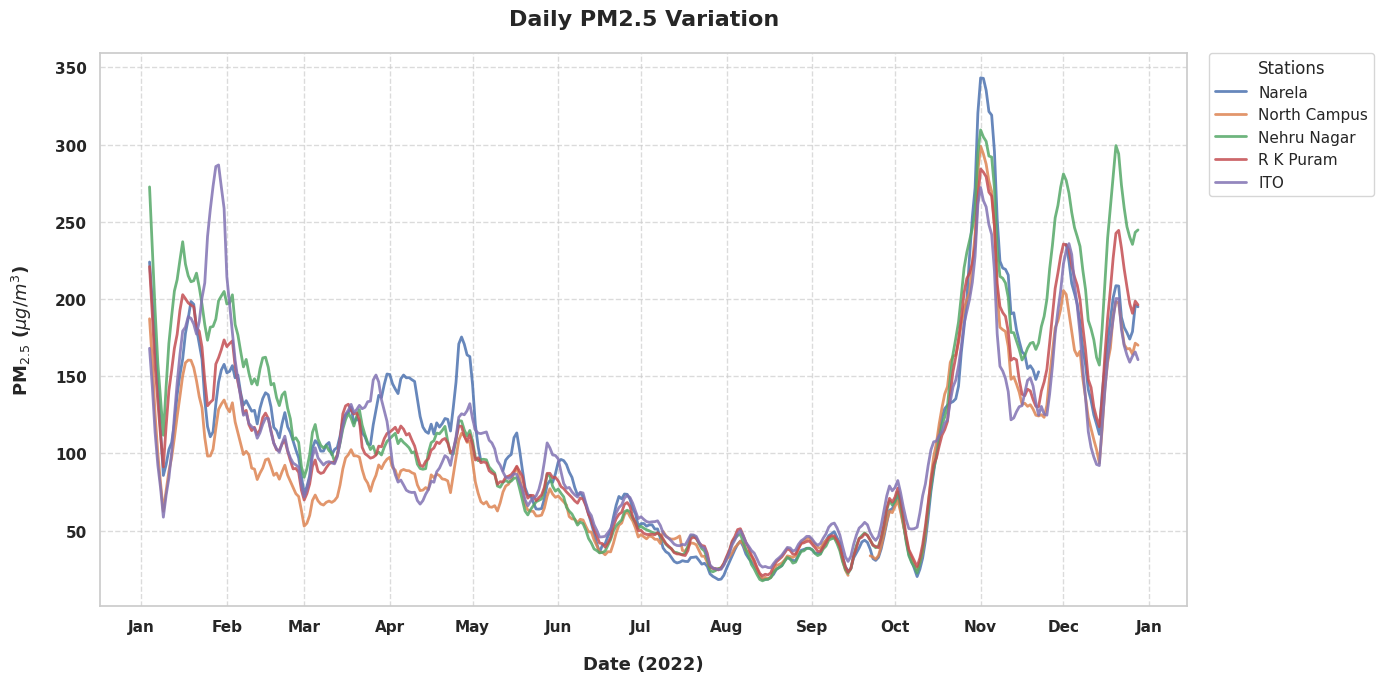

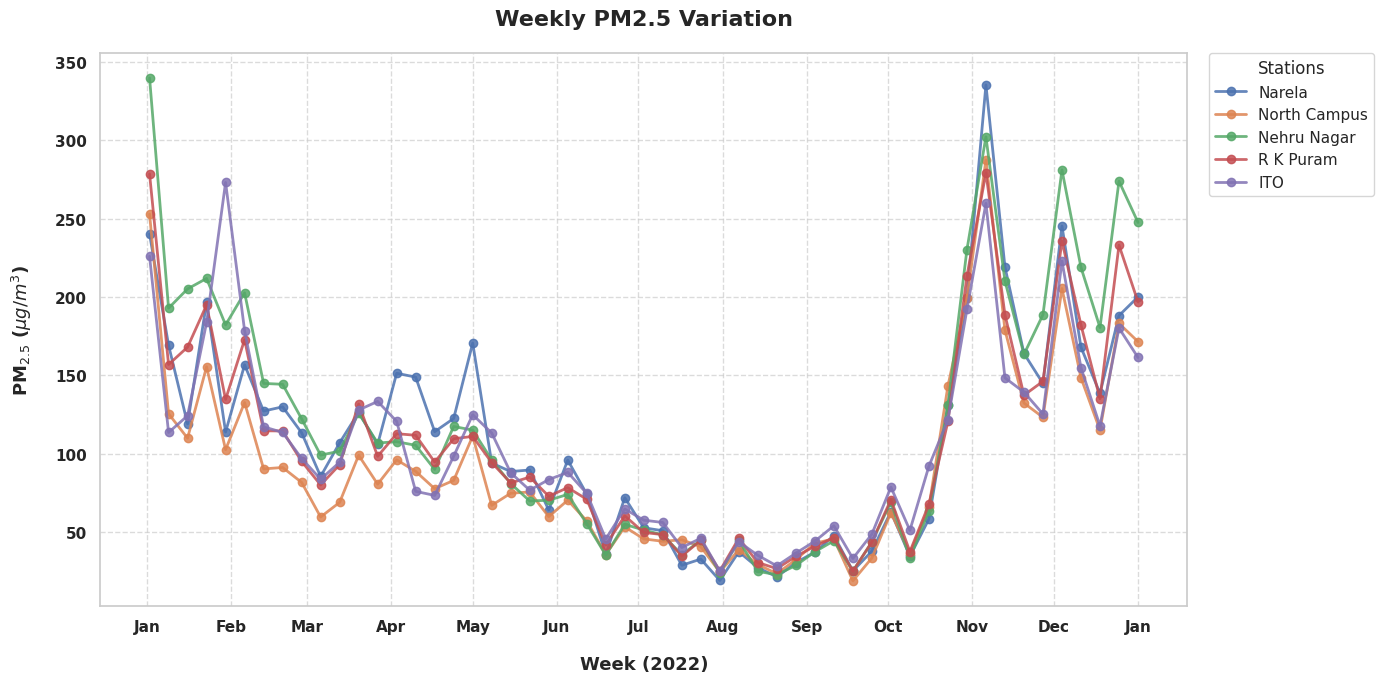

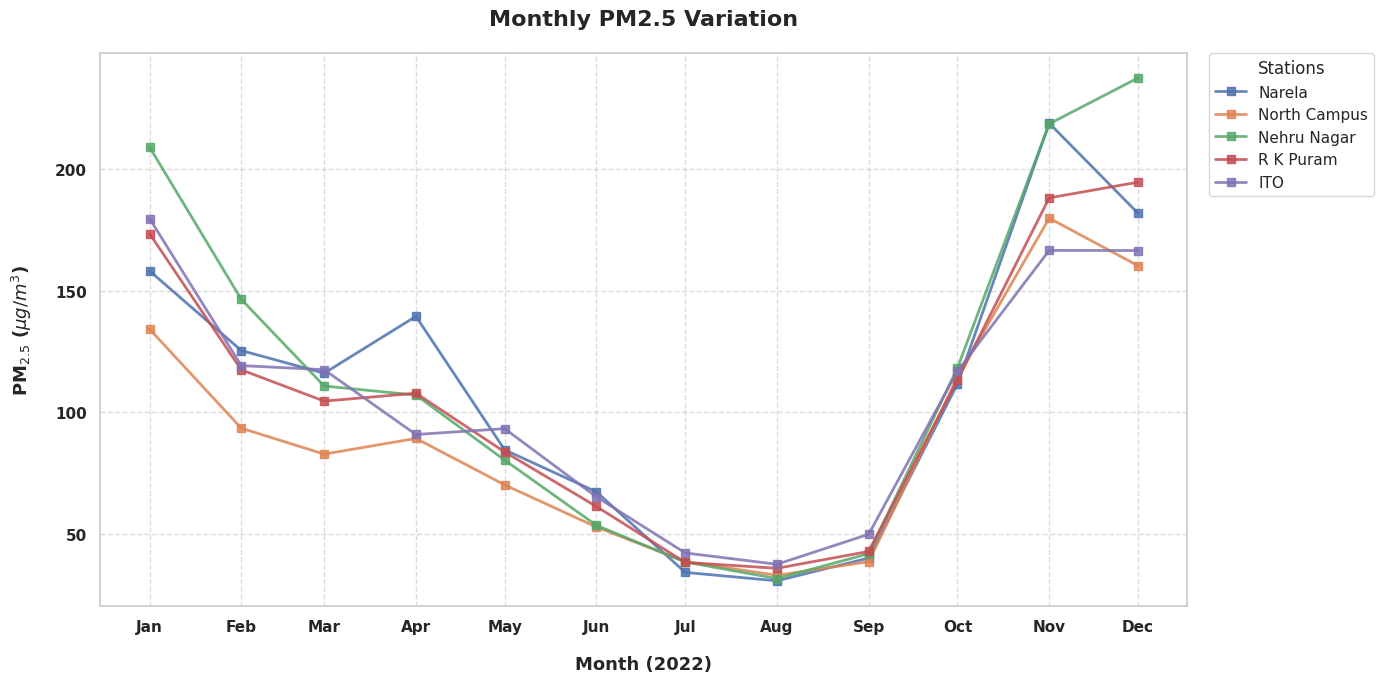

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import warnings

warnings.filterwarnings("ignore")

CSV_FILES = [
    'Raw_data_1Hr_2022_site_1426_Narela_Delhi_DPCC_1Hr.csv',
    'Raw_data_1Hr_2022_site_105_North_Campus_DU_Delhi_IMD_1Hr.csv',
    'Raw_data_1Hr_2022_site_1429_Nehru_Nagar_Delhi_DPCC_1Hr.csv',
    'Raw_data_1Hr_2022_site_124_R_K_Puram_Delhi_DPCC_1Hr.csv',
    'Raw_data_1Hr_2022_site_117_ITO_Delhi_CPCB_1Hr.csv'
]

STATION_COORDS = {
    'Narela': (77.0682, 28.8475),
    'North Campus': (77.2039, 28.6946),
    'Nehru Nagar': (77.2559, 28.5638),
    'R K Puram': (77.1868, 28.5638),
    'ITO': (77.2405, 28.6322)
}
STATION_NAMES = list(STATION_COORDS.keys())
station_dfs = []

for filepath in CSV_FILES:
    try:
        # Extract Station Name
        try:
          station_name_raw = filepath.split('_site_')[1].split('_Delhi_')[0].replace('_', ' ')
        except:
          station_name_raw = filepath

        station_name = next((s for s in STATION_NAMES if s.replace(' ', '').lower() in station_name_raw.replace(' ', '').lower()), None)

        if station_name:
            df = pd.read_csv(filepath)


            col_map = {c: 'Timestamp' for c in df.columns if c.lower() == 'timestamp'}
            df.rename(columns=col_map, inplace=True)
            df['Timestamp'] = pd.to_datetime(df['Timestamp'])
            df = df.set_index('Timestamp')


            pm_col = next((c for c in df.columns if 'PM2.5' in c or c.replace('.', '').upper() == 'PM25'), None)
            if pm_col:
                df = df[[pm_col]].dropna()
                df = df[df[pm_col] > 0]
                df.rename(columns={pm_col: station_name}, inplace=True)
                station_dfs.append(df)
            else:
                print(f"No PM2.5 column found in {filepath}")
    except Exception as e:
        print(f"Error processing {filepath}: {e}")

if not station_dfs:
    print("No data loaded. Check CSV files.")
    exit()

raw_df = pd.concat(station_dfs, axis=1)
print(f"Loaded Data. Shape: {raw_df.shape}")

diurnal_df = raw_df.groupby(raw_df.index.hour).mean()

daily_df = raw_df.resample('D').mean()

daily_smooth_df = daily_df.rolling(window=7, center=True).mean()

weekly_df = daily_df.resample('W').mean()

monthly_df = daily_df.resample('MS').mean()

def plot_comparison(data, title, xlabel, ylabel, marker=None, is_diurnal=False):
    fig, ax = plt.subplots(figsize=(14, 7))
    sns.set_theme(style="whitegrid")


    for column in data.columns:
        ax.plot(data.index, data[column], label=column, marker=marker, linewidth=2, alpha=0.85)

    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.set_ylabel(ylabel, fontsize=13, fontweight='bold', labelpad=15)
    ax.set_xlabel(xlabel, fontsize=13, fontweight='bold', labelpad=15)

    if is_diurnal:
        ax.set_xticks(range(0, 24))
        ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24)], rotation=45, fontweight='bold')
        ax.set_xlim(0, 23)
    elif len(data) > 12:
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    else:
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

    plt.xticks(fontweight='bold')
    plt.yticks(fontweight='bold')

    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title="Stations")
    ax.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
    print("\n" * 2)


plot_comparison(diurnal_df, "Diurnal PM2.5 Variation", "Hour of Day", "PM$_{2.5}$ ($\mu g/m^3$)", marker='o', is_diurnal=True)

plot_comparison(daily_smooth_df, "Daily PM2.5 Variation", "Date (2022)", "PM$_{2.5}$ ($\mu g/m^3$)", marker='None')

plot_comparison(weekly_df, "Weekly PM2.5 Variation", "Week (2022)", "PM$_{2.5}$ ($\mu g/m^3$)", marker='o')

plot_comparison(monthly_df, "Monthly PM2.5 Variation", "Month (2022)", "PM$_{2.5}$ ($\mu g/m^3$)", marker='s')

# **Task 2.4 — Insights from the 2022 Analysis**

# **1.Satellite Data Validation**

*The comparison between satellite-based PM₂.₅ estimates (WUSTL product) and ground monitoring data showed strong agreement. With R² values between 0.80 and 0.91, the satellite product successfully captures real pollution patterns across all five stations.*
*Although there are minor differences in exact values (seen through RMSE and MAE), this is normal because satellites measure aerosols in the entire atmosphere—not directly at breathing height. Weather conditions like humidity or cloud cover can also affect these estimations.*

**Takeaway:** *Satellite data works well as a reliable alternative, especially in areas where ground monitoring stations are absent or sparse.*


# **2.Seasonal Pollution Patterns**

*The monthly trends form a clear “U-shaped” pattern, reflecting Delhi’s typical pollution behavior:*

*Highest in Winter (Nov–Jan): Cold weather traps pollutants close to the ground, and biomass burning plus low wind speeds worsen the situation.*

*Lowest in Monsoon (Jul–Aug): Rain removes dust and fine particles from the air—often called the washout effect.*

*Moderate in Summer (Mar–May): Levels remain mid-range, sometimes rising due to dust storms but still much lower than winter levels.*

*In simple terms: pollution peaks in winter, drops sharply during the rainy season, and sits in the middle during the rest of the year.*

# **3.Daily (Hourly) Pollution Cycle**

*The hourly data shows a typical “two-peak” daily profile, commonly seen in large cities:*

*Morning Peak (8–10 AM): Rush-hour vehicles and the breakup of the overnight stable layer lead to higher concentrations.*

*Afternoon Dip (12–4 PM): Sunlight heats the surface, creating better atmospheric mixing, causing pollutant levels to drop.*

*Evening Peak (8–11 PM): Traffic increases again, and as temperatures cool, pollutants become trapped near the ground.*

*This reflects how both human activities and atmospheric conditions interact throughout the day.*

# **4.Spatial and Weekly Differences**

*Although all stations show similar patterns over time, the pollution levels differ by location. Stations near busy roads (like ITO or Narela) consistently recorded higher PM₂.₅, while greener or institutional locations (like North Campus) showed comparatively lower values.*

*Weekly trends suggest that Sundays may show slightly lower pollution due to reduced commuting and industrial activity—but in many cases, weather conditions still have a stronger impact than human schedules.*

# **Final Summary**

*Overall, the analysis shows that weather and seasonal patterns strongly influence Delhi’s air quality, especially through temperature inversions, rainfall, and mixing layers. The strong alignment between satellite and ground measurements also demonstrates that remote sensing is a valuable tool for large-scale air quality monitoring and decision-making.*